## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```


In [ ]:
# Assign your and your partner's names here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = ''

## **Training Word Embeddings with Neural Networks**

In this exercise, we'll train our own word embeddings from scratch using a neural network. Instead of using pre-trained embeddings like GloVe, we'll learn embeddings by training a model to predict a word from its surrounding context.

This approach is similar to the **Continuous Bag of Words (CBOW)** model from Word2Vec, where we predict a target word from its context words.

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_20newsgroups
from collections import Counter
import re

## **1. Load the Dataset**

We'll use the 20 Newsgroups dataset, which contains text posts from 20 different newsgroup topics. This dataset is perfect for learning word embeddings because it has a rich vocabulary and diverse contexts.

In [2]:
# Load a subset of newsgroups for faster training
categories = ['sci.space', 'rec.sport.baseball', 'comp.graphics', 'talk.politics.misc']
newsgroups = fetch_20newsgroups(data_home=".", subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

print(f"Number of documents: {len(newsgroups.data)}")
print(f"Categories: {newsgroups.target_names}")
print(f"\nSample text (first 300 characters):\n{newsgroups.data[0][:300]}")

Number of documents: 2239
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Sample text (first 300 characters):
I thought that was Sandy Koufax.


## **2. Preprocess the Text**

We need to:
1. Convert text to lowercase
2. Remove special characters and keep only letters
3. Tokenize into words
4. Build a vocabulary of the most common words

In [4]:
def preprocess_text(text):
    """Convert text to lowercase and extract words"""
    text = text.lower()
    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    return words

# Process all documents and collect all words
all_words = []
for doc in newsgroups.data:
    all_words.extend(preprocess_text(doc))

print(f"Total words: {len(all_words)}")
print(f"Sample words: {all_words[:20]}")

Total words: 396183
Sample words: ['i', 'thought', 'that', 'was', 'sandy', 'koufax', 'and', 'the', 'religious', 'right', 'worships', 'engines', 'smokestacks', 'landfills', 'and', 'hates', 'people', 'what', 'does', 'this']


## **3. Build the Vocabulary**

Create a dictionary that maps each unique word to a unique index. We'll only keep the most common words to keep our vocabulary manageable.

In [5]:
# Count word frequencies
word_counts = Counter(all_words)
print(f"Unique words: {len(word_counts)}")

# Keep only the most common words
vocab_size = 5000
most_common = word_counts.most_common(vocab_size)

# Create word-to-index and index-to-word mappings
word_to_idx = {word: idx for idx, (word, _) in enumerate(most_common)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

print(f"Vocabulary size: {len(word_to_idx)}")
print(f"\nMost common words: {most_common[:20]}")
print(f"\nExample mappings:")
for word in ['the', 'and', 'space', 'game']:
    if word in word_to_idx:
        print(f"  '{word}' -> index {word_to_idx[word]}")

Unique words: 27192
Vocabulary size: 5000

Most common words: [('the', 21035), ('to', 10663), ('of', 9208), ('a', 8695), ('and', 8690), ('in', 6218), ('is', 5638), ('that', 5328), ('i', 4758), ('for', 4329), ('it', 3813), ('on', 3160), ('you', 3115), ('this', 2896), ('be', 2750), ('have', 2562), ('are', 2530), ('with', 2346), ('as', 2297), ('not', 2093)]

Example mappings:
  'the' -> index 0
  'and' -> index 4
  'space' -> index 46
  'game' -> index 188


## **4. Create Training Data**

For each word in our corpus, we'll create a training example where:
- **Input**: The 2 words before and 2 words after the target word (context)
- **Output**: The target word itself

For example, in the sentence "the cat sat on the mat":
- To predict "sat": context = ["the", "cat", "on", "the"], target = "sat"

In [6]:
def create_context_target_pairs(words, word_to_idx, context_size=2):
    """Create (context, target) pairs for training"""
    pairs = []
    
    for i in range(context_size, len(words) - context_size):
        # Get target word
        target_word = words[i]
        if target_word not in word_to_idx:
            continue
        
        # Get context words (2 before + 2 after)
        context = words[i-context_size:i] + words[i+1:i+context_size+1]
        
        # Check if all context words are in vocabulary
        if all(word in word_to_idx for word in context):
            context_indices = [word_to_idx[word] for word in context]
            target_idx = word_to_idx[target_word]
            pairs.append((context_indices, target_idx))
    
    return pairs

# Create training pairs from all documents
training_pairs = []
for doc in newsgroups.data[:500]:  # Use first 500 documents for faster training
    words = preprocess_text(doc)
    pairs = create_context_target_pairs(words, word_to_idx, context_size=2)
    training_pairs.extend(pairs)

print(f"Total training examples: {len(training_pairs)}")

# Show a few examples
print(f"\nSample training pairs:")
for i in range(3):
    context_indices, target_idx = training_pairs[i]
    context_words = [idx_to_word[idx] for idx in context_indices]
    target_word = idx_to_word[target_idx]
    print(f"  Context: {context_words} -> Target: '{target_word}'")

Total training examples: 59529

Sample training pairs:
  Context: ['i', 'thought', 'was', 'sandy'] -> Target: 'that'
  Context: ['thought', 'that', 'sandy', 'koufax'] -> Target: 'was'
  Context: ['have', 'to', 'with', 'anything'] -> Target: 'do'


## **TASK 1. Define the Neural Network**

Our network will:
1. Use `nn.Embedding` to convert word indices to dense vectors
2. Flatten the context embeddings into a single vector
3. Pass through several linear layers with ReLU activations
4. Output a probability distribution over all vocabulary words

The embedding layer is where our word vectors will be learned!

In [7]:


class WordEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super(WordEmbeddingModel, self).__init__()
        
        # Embedding layer: converts word indices to dense vectors
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Neural network layers
        # Input size is context_size * 2 * embedding_dim (we have 4 context words)
        self.fc1 = nn.Linear(context_size * 2 * embedding_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, vocab_size)
        
    def forward(self, context):
        # context shape: (batch_size, context_size * 2)
        # Embed all context words
        embeds = self.embeddings(context)  # (batch_size, context_size * 2, embedding_dim)
        
        # Flatten the embeddings
        embeds = embeds.view(embeds.size(0), -1)  # (batch_size, context_size * 2 * embedding_dim)
        
        # Pass through network
        x = torch.relu(self.fc1(embeds))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output: (batch_size, vocab_size)
        
        return x

# Hyperparameters
embedding_dim = 50  # Dimension of word embeddings
context_size = 2    # Number of words before and after
learning_rate = 0.01

# Create model
model = WordEmbeddingModel(vocab_size, embedding_dim, context_size)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

WordEmbeddingModel(
  (embeddings): Embedding(5000, 50)
  (fc1): Linear(in_features=200, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=5000, bias=True)
)

Total parameters: 937240


## **5. Training Setup**

We'll use:
- **Cross Entropy Loss**: Good for classification problems
- **SGD Optimizer**: Stochastic Gradient Descent to update weights

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

print("Training setup complete!")

Training setup complete!


## **TASK 2. Train the Model**

We'll train for several epochs, where each epoch goes through all training examples. The model learns to predict words from their context, and in doing so, learns meaningful word embeddings.

In [9]:
# Convert training data to tensors
contexts = torch.tensor([pair[0] for pair in training_pairs], dtype=torch.long)
targets = torch.tensor([pair[1] for pair in training_pairs], dtype=torch.long)

print(f"Training data shapes:")
print(f"  Contexts: {contexts.shape}")
print(f"  Targets: {targets.shape}")

# Training loop
num_epochs = 100
batch_size = 128
losses = []

print("Starting training...\n")

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for param_group in optimizer.param_groups:
        param_group['lr'] = learning_rate * (0.95 ** epoch)  # Decay learning rate each epoch
    
    # Mini-batch training
    for i in range(0, len(contexts), batch_size):
        # Get batch
        batch_contexts = contexts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]
        
        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_contexts)
        
        # Compute loss
        loss = criterion(outputs, batch_targets)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Training data shapes:
  Contexts: torch.Size([59529, 4])
  Targets: torch.Size([59529])
Starting training...

Epoch 1/100, Loss: 6.7078
Epoch 2/100, Loss: 6.0546
Epoch 3/100, Loss: 5.7114
Epoch 4/100, Loss: 5.4722
Epoch 5/100, Loss: 5.2883
Epoch 6/100, Loss: 5.1259
Epoch 7/100, Loss: 4.9716
Epoch 8/100, Loss: 4.8406
Epoch 9/100, Loss: 4.7146
Epoch 10/100, Loss: 4.6001
Epoch 11/100, Loss: 4.4855
Epoch 12/100, Loss: 4.3748
Epoch 13/100, Loss: 4.2574
Epoch 14/100, Loss: 4.1568
Epoch 15/100, Loss: 4.0583
Epoch 16/100, Loss: 3.9573
Epoch 17/100, Loss: 3.8626
Epoch 18/100, Loss: 3.7744
Epoch 19/100, Loss: 3.6850
Epoch 20/100, Loss: 3.5956
Epoch 21/100, Loss: 3.5124
Epoch 22/100, Loss: 3.4270
Epoch 23/100, Loss: 3.3444
Epoch 24/100, Loss: 3.2577
Epoch 25/100, Loss: 3.1707
Epoch 26/100, Loss: 3.0943
Epoch 27/100, Loss: 3.0194
Epoch 28/100, Loss: 2.9506
Epoch 29/100, Loss: 2.8740
Epoch 30/100, Loss: 2.8039
Epoch 31/100, Loss: 2.7381
Epoch 32/100, Loss: 2.6732
Epoch 33/100, Loss: 2.6094
Epoch 34

## **8. Visualize Training Progress**

Let's plot the loss over epochs to see how well the model learned.

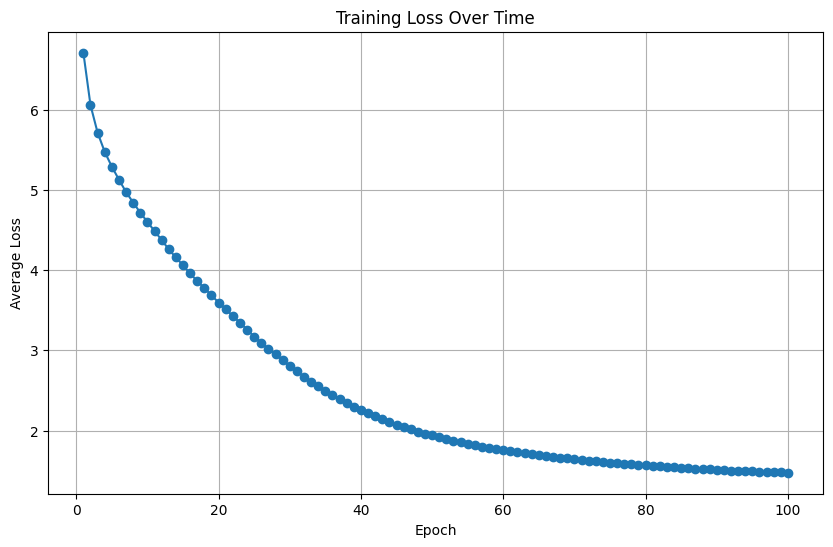

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

## **9. Extract Learned Embeddings**

Now that we've trained the model, let's extract the learned word embeddings from the embedding layer.

In [11]:
# Get the embedding weights
embedding_weights = model.embeddings.weight.data.numpy()

print(f"Embedding matrix shape: {embedding_weights.shape}")
print(f"Each word is represented by a {embedding_dim}-dimensional vector")

# Look at a specific word's embedding
word = 'space'
if word in word_to_idx:
    word_idx = word_to_idx[word]
    word_embedding = embedding_weights[word_idx]
    print(f"\nEmbedding for '{word}' (first 10 dimensions):")
    print(word_embedding[:10])

Embedding matrix shape: (5000, 50)
Each word is represented by a 50-dimensional vector

Embedding for 'space' (first 10 dimensions):
[-0.1942671  -0.3278426   0.5178049  -1.1074959  -0.7330983  -0.70320666
 -0.28215122  0.2296171   0.23326042  0.18914448]


## **10. Test Word Similarity**

Let's test if our embeddings capture semantic similarity by finding words similar to a query word using cosine similarity.

In [12]:
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two vectors"""
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2)

def find_similar_words(word, word_to_idx, idx_to_word, embeddings, top_k=5):
    """Find the most similar words to a given word"""
    if word not in word_to_idx:
        print(f"'{word}' not in vocabulary")
        return
    
    word_idx = word_to_idx[word]
    word_embedding = embeddings[word_idx]
    
    # Compute similarities with all words
    similarities = []
    for idx in range(len(embeddings)):
        if idx != word_idx:  # Skip the word itself
            sim = cosine_similarity(word_embedding, embeddings[idx])
            similarities.append((idx, sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # Get top k
    print(f"\nWords most similar to '{word}':")
    for idx, sim in similarities[:top_k]:
        print(f"  {idx_to_word[idx]}: {sim:.4f}")

# Test with some words
test_words = ['space', 'baseball', 'computer', 'government', 'game']
for word in test_words:
    if word in word_to_idx:
        find_similar_words(word, word_to_idx, idx_to_word, embedding_weights, top_k=5)


Words most similar to 'space':
  television: 0.5819
  evaluation: 0.5296
  human: 0.4895
  motorola: 0.4846
  phils: 0.4402

Words most similar to 'baseball':
  american: 0.5023
  operational: 0.4761
  learning: 0.4399
  deputy: 0.4317
  why: 0.4266

Words most similar to 'computer':
  nonprofit: 0.4896
  greg: 0.4697
  suggests: 0.4571
  mixed: 0.4420
  non: 0.4312

Words most similar to 'government':
  artist: 0.5409
  score: 0.4824
  conclusion: 0.4434
  uk: 0.4365
  archive: 0.4308

Words most similar to 'game':
  bobby: 0.4729
  rare: 0.4575
  sounding: 0.4309
  vandenberg: 0.4172
  vague: 0.4112


## **11. Visualize Embeddings with t-SNE**

Let's use t-SNE to reduce our 50-dimensional embeddings to 2D for visualization. We'll look at a selection of interesting words from different topics.

In [13]:
# Select interesting words to visualize
words_to_visualize = {
    'Space': ['space', 'launch', 'orbit', 'satellite', 'nasa', 'moon', 'rocket', 'shuttle'],
    'Baseball': ['baseball', 'game', 'team', 'player', 'win', 'ball', 'season', 'hit'],
    'Computing': ['computer', 'software', 'program', 'system', 'data', 'file', 'graphics', 'image'],
    'Politics': ['government', 'people', 'law', 'president', 'rights', 'state', 'political', 'public']
}

# Flatten and filter words that exist in vocabulary
viz_words = []
word_categories = {}
for category, words in words_to_visualize.items():
    for word in words:
        if word in word_to_idx:
            viz_words.append(word)
            word_categories[word] = category

print(f"Visualizing {len(viz_words)} words")
print(f"Words: {viz_words}")

Visualizing 32 words
Words: ['space', 'launch', 'orbit', 'satellite', 'nasa', 'moon', 'rocket', 'shuttle', 'baseball', 'game', 'team', 'player', 'win', 'ball', 'season', 'hit', 'computer', 'software', 'program', 'system', 'data', 'file', 'graphics', 'image', 'government', 'people', 'law', 'president', 'rights', 'state', 'political', 'public']


In [14]:
# Extract embeddings for these words
viz_indices = [word_to_idx[word] for word in viz_words]
viz_embeddings = embedding_weights[viz_indices]

print(f"Shape of embeddings to visualize: {viz_embeddings.shape}")

Shape of embeddings to visualize: (32, 50)


In [15]:
# Apply t-SNE
print("Applying t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
embeddings_2d = tsne.fit_transform(viz_embeddings)
print("t-SNE complete!")

Applying t-SNE...
t-SNE complete!


## **12. Plot Embeddings**

Now let's create a visualization of our word embeddings. This function is adapted from the t-SNE homework.

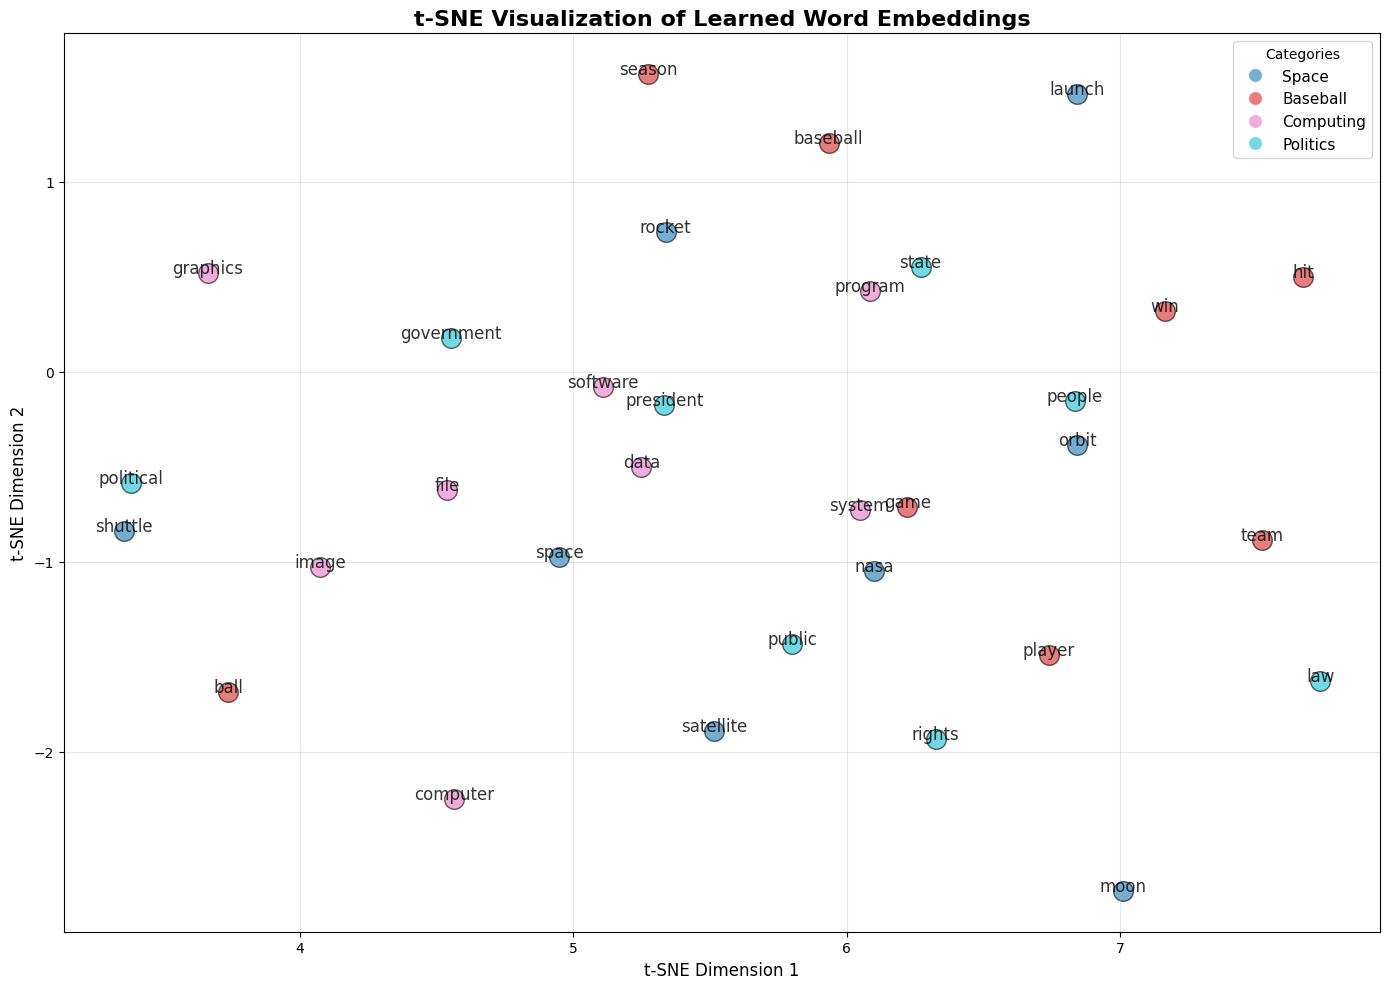

In [16]:
def plot_embeddings(words_to_plot, word_vectors_2d, word_categories, category_dict):
    """Plot word embeddings in 2D space with category colors"""
    plt.figure(figsize=(14, 10))
    
    # Get unique categories
    categories = list(category_dict.keys())
    
    # Create a color map for categories
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
    category_colors = {cat: colors[i] for i, cat in enumerate(categories)}
    
    # Plot each word
    for i, word in enumerate(words_to_plot):
        category = word_categories[word]
        x, y = word_vectors_2d[i]
        
        plt.scatter(x, y, c=[category_colors[category]], s=200, alpha=0.6, edgecolors='black', linewidth=1)
        plt.annotate(word, (x, y), fontsize=12, alpha=0.8, ha='center')
    
    # Create legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                   markerfacecolor=category_colors[cat], 
                                   markersize=10, label=cat, alpha=0.6)
                       for cat in categories]
    plt.legend(handles=legend_elements, loc='best', fontsize=11, title='Categories')
    
    plt.title('t-SNE Visualization of Learned Word Embeddings', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot the embeddings
plot_embeddings(viz_words, embeddings_2d, word_categories, words_to_visualize)

## **13. Analysis Questions**

Based on your results, consider the following:

1. **Clustering**: Do words from the same category (space, baseball, computing, politics) cluster together? What does this tell you about what the model learned?

2. **Training**: How did the loss decrease during training? Did it converge smoothly or were there fluctuations?

3. **Similarity**: When you looked at similar words, did the results make semantic sense? For example, are words related to "space" similar to each other?

4. **Embedding Quality**: Compare these embeddings to pre-trained ones like GloVe. What are the advantages and disadvantages of training your own embeddings?

5. **Improvements**: How could you improve these embeddings? Consider:
   - Using more training data
   - Training for more epochs
   - Adjusting the embedding dimension
   - Using a different context window size
   - Adding more hidden layers or neurons

## **14. Summary**

In this exercise, you learned:

1. **Text Preprocessing**: How to clean and tokenize text data, and build a vocabulary

2. **Word Embeddings**: How `nn.Embedding` works in PyTorch to convert word indices to dense vectors

3. **Context-Based Learning**: How to train embeddings by predicting words from their context (CBOW approach)

4. **Neural Networks for NLP**: How to build a network that processes multiple input words and combines their embeddings

5. **Embedding Visualization**: How to use t-SNE to visualize high-dimensional embeddings in 2D

### Key Concepts:

- **Embeddings are learned representations**: The embedding layer learns to map words to vectors such that words used in similar contexts have similar vectors

- **Context matters**: By training on word contexts, the model learns semantic relationships

- **Dimensionality reduction**: t-SNE helps us visualize high-dimensional embeddings while preserving local structure

### Next Steps:

- Try the **Skip-gram** approach (predict context from target word)
- Experiment with **negative sampling** to improve training
- Use pre-trained embeddings (GloVe, Word2Vec, FastText) for downstream tasks
- Explore **transformer-based embeddings** (BERT, GPT) that capture context dynamically